In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

from matplotlib import pyplot as plt
from vrAnalysis.database import get_database
from vrAnalysis.helpers import Timer
from vrAnalysis.helpers.plotting import save_figure
from vrAnalysis.sessions import B2Session
from dimensionality_manuscript.registry import PopulationRegistry, RegistryPaths
from dimensionality_manuscript import (
    RegressionConfig,
    VectorGainRankConfig,
    # RRRToExternalLatentsConfig,
    RegressionDimensionalitySweepConfig,
    RegressionPlacefieldResidualConfig,
    RegressionResidualStructureConfig,
    ResultsStore,
    ResultsAggregator,
    RankModelsSweepConfig,
    GainRegressionConfig,
)

# get session database
sessiondb = get_database("vrSessions")

# get population registry
registry = PopulationRegistry()

registry_paths = RegistryPaths()
figure_path = registry_paths.figure_path / "figure2"
if not figure_path.exists():
    figure_path.mkdir(parents=True, exist_ok=True)

In [2]:
sessions = sessiondb.iter_sessions(imaging=True, experimentType="Blender VR")
store = ResultsStore()

# Main results
cfg = RegressionConfig()
results = ResultsAggregator(cfg, store, sessions)

# Rank varying additive models (called VectorGain)
cfg_vector = VectorGainRankConfig()
results_vector = ResultsAggregator(cfg_vector, store, sessions)

# Regression dimensionality sweep 
cfg_sweep = RegressionDimensionalitySweepConfig()
results_sweep = ResultsAggregator(cfg_sweep, store, sessions)

# External to latents regressions
# cfg = RRRToExternalLatentsConfig()
# results_latents = ResultsAggregator(cfg, store, sessions)

# Place-field residual summaries
cfg_residual = RegressionPlacefieldResidualConfig()
results_residual = ResultsAggregator(cfg_residual, store, sessions)

cfg_residual_structure = RegressionResidualStructureConfig()
results_residual_structure = ResultsAggregator(cfg_residual_structure, store, sessions)

# Rank sweep 
cfg_rank_sweep = RankModelsSweepConfig()
results_rank_sweep = ResultsAggregator(cfg_rank_sweep, store, sessions)

# Trial-wise place-field gain regression
cfg_gain = GainRegressionConfig()
results_gain = ResultsAggregator(cfg_gain, store, sessions)

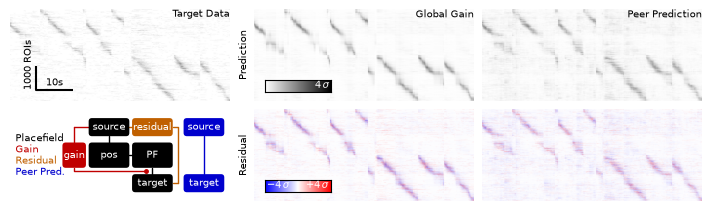

In [16]:
from dimensionality_manuscript.figure_scripts.figure2 import ModelZooUltraCondensedConfig, ModelPredictionsFigureViewer

cfg = ModelZooUltraCondensedConfig(
    box_width=2.25,
    gain_width=1.3,
    latent_height_scale=1.4,
    lane_gap=0.15,
    row_gap=0.35,
    group_gap=0.3,
    structured_bypass_offset=0.3,
    label_column_width=2.0,
    arrow_linewidth=1.0,
    arrow_mutation_scale=6.0,
    box_fontsize=7,
    label_fontsize=7,
    junction_dot_size=2.5,
    horizontal_connections_as_lines=True,
    vertical_connections_as_lines=True,
    # figsize=(4.5, 1.25),
)

viewer = ModelPredictionsFigureViewer(
    results,
    registry,
    include_structured_additive=False,
    mouse="ATL027",
    session="ATL027/2023-08-04/702",
    activity_parameters_name="std",
    xslice=slice(0, 364),
    vmax=4.0,
    scale_bar_x=0.12,
    scale_bar_y=0.12,
    scale_bar_seconds=10.0,
    scale_bar_num_rois=1000,
    colorscale_inset_rect=(0.05, 0.1, 0.3, 0.13),
    figsize=(7.0, 2.0),
    fontsize=7,
    zoo_config=cfg,
)


show_viewer = False
if show_viewer:
    viewer.show()
else:
    fig = viewer.plot(viewer.state)
    plt.show()

    save = True
    if save:
        save_figure(fig, figure_path / "model_predictions_figure")

C:\Users\Andrew\Documents\GitHub\vrAnalysis\dimensionality_manuscript\pipeline\aggregate.py:44: RuntimeWarning: Mean of empty slice
  out[i] = np.nanmean(arr[mouse_names == mouse], axis=0)


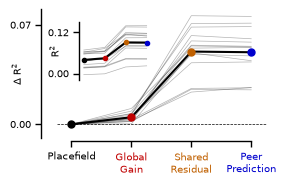

In [23]:
from dimensionality_manuscript.figure_scripts.figure2 import ModelPerformanceViewer

viewer = ModelPerformanceViewer(
    results,
    spks_type = "sigrebase",
    activity_parameters_name = "std",
    metric = "r2",
    avg_by_mouse = True,
    reference_model = "internal_placefield_1d",
    include_structured_additive=True,
    ylim=(-0.01, 0.081),
    ytick_max = 0.07,
    legend_x = 5.0,
    legend_y = 0.085,
    legend_dy = -0.01,
    show_inset = True,
    figsize = (2.75, 1.75),
    fontsize = 7,
    inset_fontsize=7,
    inset_x=0.15,
    inset_y=0.45,
    inset_width=0.3,
    inset_height=0.45,
    inset_ytick_max=0.12,
    inset_ylim=(-0.02, 0.15),
    zero_line_pad=0.25,
)


show_viewer = False
if show_viewer:
    viewer.show()
else:
    fig = viewer.plot(viewer.state)
    plt.show()

    save = True
    if save:
        save_figure(fig, figure_path / "model_performance_summary")

In [1]:
from dimensionality_manuscript.figure_scripts.figure2 import ModelPlacefieldResidualViewer

viewer = ModelPlacefieldResidualViewer(
    results_residual,
    include_structured_additive=True,
    spks_type = "sigrebase",
    activity_parameters_name = "std",
    metric="r2_shared",
    statistic="median",
    fold="infold",
    main_sharey=True,
    main_relative=True,
    within_text_x=0.05,
    outside_text_x=0.05,
    within_text_y=0.875,
    outside_text_y=0.875,
    inset_x=0.2,
    inset_y=0.1,
    inset_width=0.4,
    inset_show="all",
    inset_sharey=True,
    inset_relative=False,
    include_inset=False,
    figsize = (4.25, 1.75),
    fontsize = 7,
)

show_viewer = True
if show_viewer:
    viewer.show()
else:
    fig = viewer.plot(viewer.state)
    plt.show()

    save = True
    if save:
        save_figure(fig, figure_path / "model_inoutplacefield_residual_summary")

NameError: name 'results_residual' is not defined

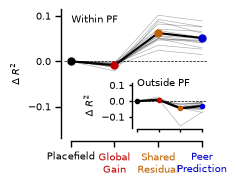

In [12]:
from dimensionality_manuscript.figure_scripts.figure2 import ModelPlacefieldResidualInsetViewer

viewer = ModelPlacefieldResidualInsetViewer(
    results_residual,
    include_structured_additive=True,
    spks_type = "sigrebase",
    activity_parameters_name = "std",
    metric="r2_weighted",
    statistic="median",
    fold="infold",
    sharey=True,
    relative=True,
    within_text_x=0.05,
    outside_text_x=0.05,
    within_text_y=0.875,
    outside_text_y=0.875,
    inset_x=0.475,
    inset_y=0.075,
    inset_width=0.5,
    inset_height=0.35,
    figsize = (2.25, 1.75),
    fontsize = 7,
)

show_viewer = False
if show_viewer:
    viewer.show()
else:
    fig = viewer.plot(viewer.state)
    plt.show()

    save = True
    if save:
        save_figure(fig, figure_path / "model_residual_withinoutside_condensed_summary")

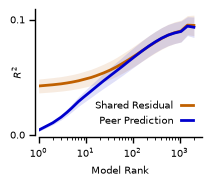

In [13]:
from dimensionality_manuscript.figure_scripts.figure2 import RankModelsSweepViewer

viewer = RankModelsSweepViewer(
    results_rank_sweep,
    xlog=True,
    structured_additive="internal",
    figsize=(2.0, 1.75),
    fontsize=7,
    legend_options=dict(
        loc="lower right",
        handlelength=1.2,
        markerfirst=False,
    )
)


show_viewer = False
if show_viewer:
    viewer.show()
    
else:
    fig = viewer.plot(viewer.state)
    plt.show()

    save = True
    if save:
        save_figure(fig, figure_path / "rank_models_sweep")

In [ ]:
# from dimensionality_manuscript.figure_scripts.figure2 import ModelPlacefieldResidualExplorer

# viewer = ModelPlacefieldResidualExplorer(
#     results_residual,
# )

# show_viewer = True
# if show_viewer:
#     viewer.show()
# else:
#     fig = viewer.plot(viewer.state)
#     plt.show()

#     save = False
#     if save:
#         save_figure(fig, figure_path / "model_inoutplacefield_residual_summary")

In [ ]:
from dimensionality_manuscript.figure_scripts.figure2 import RegressionResidualStructureViewer

viewer = RegressionResidualStructureViewer(
    results_residual_structure,
    mouse="ATL027",
    session="ATL027/2023-08-04/702",
    model_name="internal_placefield_1d",
    residual_mode = "additive",
    sort_method = "environment",
    # xslice = slice(0, 2000),
    vmax = 4.0,
    covariance_vmax = 0.5,
    position_height = 0.35,
    env_gap = 0.2,
    covariance_width = 1.0,
    fontsize = 8.0,
    figsize = (12.0, 6.0),
)

show_viewer = True
if show_viewer:
    viewer.show()
else:
    fig = viewer.plot(viewer.state)
    plt.show()

    save = False
    if save:
        save_figure(fig, figure_path / "residual_example")

{'baseline_model': 'internal_placefield_1d',
 'comparison_models': ['internal_placefield_1d_gain',
                       'internal_placefield_1d_structured_additive',
                       'rrr'],
 'converged': True,
 'data':       mouse  session          model        r2
0    ATL012      0.0             pf  0.004360
1    ATL012      0.0        pf_gain  0.008349
2    ATL012      0.0  peer_residual  0.079975
3    ATL012      0.0           peer  0.082331
4    ATL012      1.0             pf  0.004657
..      ...      ...            ...       ...
555  ATL076     14.0           peer  0.067699
556  ATL076     15.0             pf  0.032815
557  ATL076     15.0        pf_gain  0.036833
558  ATL076     15.0  peer_residual  0.062541
559  ATL076     15.0           peer  0.062031

[560 rows x 4 columns],
 'estimation': 'REML',
 'fixed_effects':                                     beta        se         z             p  \
Intercept                       0.016978  0.007863  2.159334  3.082427e-02  

c:\Users\Andrew\AppData\Local\miniforge3\envs\vrAnalysis\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


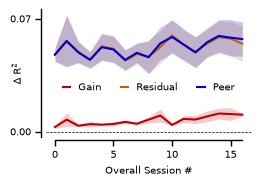

In [23]:
from dimensionality_manuscript.figure_scripts.figure2 import RegressionFamiliarityViewer

viewer = RegressionFamiliarityViewer(
    results,
    include_structured_additive=True,
    spks_type = "sigrebase",
    activity_parameters_name = "std",
    value_mode = "improvement",
    style = "errorPlot",
    se = True,
    min_mice = 2,
    auto_ylim = True,
    legend_options = dict(
        loc="center",
        ncols=3,
        handlelength=0.8,
        visible=True,
        y_offset = -0.11,
    ),
    show_zero_line=True,
    figsize = (2.5, 1.75),
    fontsize = 7,
)

report_stats = True
if report_stats:
    from pprint import pprint
    stats = viewer.measure_statistics(viewer.state)
    pprint(stats)

show_viewer = False
if show_viewer:
    viewer.show()

else:
    fig = viewer.plot(viewer.state)
    plt.show()

    save = True
    if save:
        save_figure(fig, figure_path / "regression_by_familiarity")

In [4]:
from dimensionality_manuscript.figure_scripts.figure2 import RegressionFamiliarityByEnvViewer

viewer = RegressionFamiliarityByEnvViewer(
    results,
    spks_type = "sigrebase",
    activity_parameters_name = "std",
    style = "errorPlot",
    auto_ylim = True,
    legend_options = dict(visible=False),
    show_zero_line=True,
    figsize = (4.5, 1.75),
    fontsize = 7,
)

show_viewer = True
if show_viewer:
    viewer.show()

else:
    fig = viewer.plot(viewer.state)
    plt.show()

    save = True
    if save:
        save_figure(fig, figure_path / "regression_by_familiarity_by_env")

In [ ]:
from dimensionality_manuscript.figure_scripts.figure2 import ModelPlacefieldResidualFamiliarityViewer

viewer = ModelPlacefieldResidualFamiliarityViewer(
    results_residual,
    activity_parameters_name = "std",
    normalized=False,
    quality=False,
    sharey=True,
    relative=True,
    within_only=False,
    figsize = (4.5, 1.75),
    fontsize = 7,
    legend_options = dict(
        loc="lower left",
        fontsize_scale=1.0,
    )
)


show_viewer = True
if show_viewer:
    viewer.show()
else:
    fig = viewer.plot(viewer.state)
    plt.show()

    save = True
    if save:
        save_figure(fig, figure_path / "model_placefield_residual_familiarity")

: 

In [6]:
# from dimensionality_manuscript.figure_scripts.figure2 import RegressionDimSweepViewer

# viewer = RegressionDimSweepViewer(
#     results_sweep,
#     activity_parameters_name="std",
#     metric = "r2",
#     se = True,
#     xlog = True,
#     linewidth = 2.0,
#     fill_alpha = 0.2,
#     figsize = (2.5, 1.75),
#     fontsize = 7,
# )


# show_viewer = True
# if show_viewer:
#     viewer.show()
# else:
#     fig = viewer.plot(viewer.state)
#     plt.show()

#     save = True
#     if save:
#         save_figure(fig, figure_path / "regression_dim_sweep")

2026-08-11 23:00:17,316 [INFO] normalizing data across axis=1
2026-08-11 23:00:17,317 [INFO] projecting out mean along axis=0
2026-08-11 23:00:17,318 [INFO] data normalized, 0.00sec
2026-08-11 23:00:17,319 [INFO] sorting activity: 2199 valid samples by 40 timepoints
2026-08-11 23:00:17,329 [INFO] n_PCs = 40 computed, 0.01sec
2026-08-11 23:00:17,444 [INFO] 100 clusters computed, time 0.13sec
2026-08-11 23:00:34,447 [INFO] clusters sorted, time 17.13sec
2026-08-11 23:00:34,574 [INFO] clusters upsampled, time 17.26sec
2026-08-11 23:00:34,576 [INFO] rastermap complete, time 17.26sec


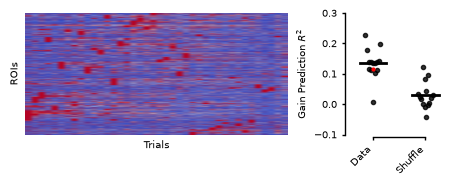

In [24]:
import numpy as np
from dimensionality_manuscript.figure_scripts.figure2 import PlacefieldGainViewer

sessions = sessiondb.iter_sessions(imaging=True, experimentType="Blender VR", session_params={"spks_type": "sigrebase"})
viewer = PlacefieldGainViewer(
    sessions,
    results_gain,
    mouse="ATL027",
    session="ATL027/2023-08-04/702",
    environment=1,
    interpolation="auto",
    include_covariance=False,
    include_familiarity=False,
    sort_method="rastermap_gain",
    gain_transform="sqrt",
    gain_vmax=np.sqrt(2.0),
    covariance_vmax=np.sqrt(2.0),
    beewidth=0.15,
    figsize = (4.5, 1.75),
    fontsize = 7,
)


show_viewer = False
if show_viewer:
    viewer.show()
    
else:
    fig = viewer.plot(viewer.state)
    plt.show()

    save = True
    if save:
        save_figure(fig, figure_path / "placefield_gain_example")

In [ ]:
# from dimensionality_manuscript.figure_scripts.figure2 import DimSweepLatentsViewer

# show_viewer = True
# viewer = DimSweepLatentsViewer(
#     results_latents,
#     results_sweep,
#     latents_show = "internal",
#     metric = "r2",
#     se = True,
#     xlog = True,
#     linewidth = 2.0,
#     fill_alpha = 0.1,
#     figsize = (4.5, 2.5),
#     fontsize = 8,
# )
# if show_viewer:
#     viewer.show()
# else:
#     fig = viewer.plot(viewer.state)
#     plt.show()

#     save = True
#     if save:
#         save_figure(fig, figure_path / "dim_sweep_latents")

In [ ]:
# from dimensionality_manuscript.figure_scripts.figure2 import RRRExternalLatentsViewer

# show_viewer = True
# viewer = RRRExternalLatentsViewer(
#     results_latents,
#     normalize = False,
#     agg_method = "median",
#     latents_show = "internal",
#     beewidth = 0.25,
#     dodge_offset = 0.2,
#     width_rank_axis = 0.8,
#     rank_axis_log = False,
#     inset_num_dims = 20,
#     figsize = (5.0, 3.0),
#     alpha = 0.4,
#     fontsize = 8,
# )
# if show_viewer:
#     viewer.show()
# else:
#     fig = viewer.plot(viewer.state)
#     plt.show()

#     save = True
#     if save:
#         save_figure(fig, figure_path / "rrr_to_external_latents_score")

In [9]:
# from dimensionality_manuscript.figure_scripts.figure2 import ModelZooCondensed, ModelZooSchematicConfig

# cfg = ModelZooSchematicConfig(
#     gain_width=1.0,
#     col_gap=0.15,
#     row_gap=0.45,
#     arrow_linewidth=1.0,
#     arrow_mutation_scale=6.00,
#     box_fontsize=7,
#     junction_dot_size=2.5,
#     figsize=(4.5, 1.25),
# )
# viewer = ModelZooCondensed(cfg)


# show_viewer = True
# if show_viewer:
#     viewer.show()

# else:
#     fig = viewer.plot(viewer.state)
#     plt.show()

#     save = True
#     if save:
#         save_figure(fig, figure_path / "model_zoo_condensed")

In [8]:
from dimensionality_manuscript.figure_scripts.figure2 import (
    ModelZooUltraCondensed,
    ModelZooUltraCondensedConfig,
)

cfg = ModelZooUltraCondensedConfig(
    gain_width=1.3,
    latent_height_scale=1.4,
    lane_gap=0.45,
    row_gap=0.35,
    group_gap=0.3,
    structured_bypass_offset=0.3,
    arrow_linewidth=1.0,
    arrow_mutation_scale=6.0,
    box_fontsize=7,
    label_fontsize=7,
    junction_dot_size=2.5,
    figsize=(4.5, 1.25),
)

viewer = ModelZooUltraCondensed(cfg)

show_viewer = True
if show_viewer:
    viewer.show()

else:
    fig = viewer.plot(viewer.state)
    plt.show()

    save = True
    if save:
        save_figure(fig, figure_path / "model_zoo_ultra_condensed")

In [ ]:
from dimensionality_manuscript.figure_scripts.figure2 import RegressionPredictionViewer

viewer = RegressionPredictionViewer(
    results,
    registry,
    model_name="external_placefield_1d",
)
# viewer.show()

In [ ]:
# Make a stack of rasterplots
from dimensionality_manuscript.figure_scripts.figure2 import ModelRasterFocus

mouse_name = "ATL027"
date = "2023-08-07"#"2023-07-27"
session_id = "701"
spks_type = "sigrebase"
session = B2Session.create(mouse_name, date, session_id, dict(spks_type=spks_type))

model_names = ["internal_placefield_1d", "internal_placefield_1d_gain", "rrr"]
fig_props = dict(
    activity_parameters_name="std",
    include_data_raster=True,
    include_error_column=True,
    include_sample_fit_curve=False,
    sample_fit_metric="r2",
    zscore=False,
    subtract_median=False,
    xslice=slice(0, 400),
    vmax=5.0,
    figsize=(6.0, 3.5),
    scale_bar_seconds=20.0,
)
viewer = ModelRasterFocus(session, spks_type, model_names, registry=registry, **fig_props)
# viewer.show()

# save_figure(viewer.plot(viewer.state), figure_path / "stacked_model_rasters")